In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load the data

In [107]:
df= pd.read_csv('../data/prepared.csv')
df.head()

,squaremeters,numberofrooms,hasyard,haspool,floors,citycode,citypartrange,numprevowners,made,isnewbuilt,hasstormprotector,basement,attic,garage,hasstorageroom,hasguestroom,price
0,75523,3,0,1,63,9373,3,8,2005,0,1,4313,9005,956,0,7,7559081.5
1,80771,39,1,1,98,39381,8,6,2015,1,0,3653,2436,128,1,2,8085989.5
2,55712,58,0,1,19,34457,6,8,2021,0,0,2937,8852,135,1,9,5574642.1
3,32316,47,0,0,6,27939,10,4,2012,0,1,659,7141,359,0,3,3232561.2
4,70429,19,1,1,90,38045,3,7,1990,1,0,8435,2429,292,1,4,7055052.0


In [108]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   squaremeters       10000 non-null  int64  
 1   numberofrooms      10000 non-null  int64  
 2   hasyard            10000 non-null  int64  
 3   haspool            10000 non-null  int64  
 4   floors             10000 non-null  int64  
 5   citycode           10000 non-null  int64  
 6   citypartrange      10000 non-null  int64  
 7   numprevowners      10000 non-null  int64  
 8   made               10000 non-null  int64  
 9   isnewbuilt         10000 non-null  int64  
 10  hasstormprotector  10000 non-null  int64  
 11  basement           10000 non-null  int64  
 12  attic              10000 non-null  int64  
 13  garage             10000 non-null  int64  
 14  hasstorageroom     10000 non-null  int64  
 15  hasguestroom       10000 non-null  int64  
 16  price              10000 non-null 

In [109]:
# Check the datatypes
(
    pd.DataFrame({
        'columns': df.columns,
        'Data Types': df.dtypes
    })
)

,columns,Data Types
squaremeters,squaremeters,int64
numberofrooms,numberofrooms,int64
hasyard,hasyard,int64
haspool,haspool,int64
floors,floors,int64
citycode,citycode,int64
citypartrange,citypartrange,int64
numprevowners,numprevowners,int64
made,made,int64
isnewbuilt,isnewbuilt,int64


In [110]:
df[['hasyard', 'haspool', 
    'isnewbuilt', 'hasstormprotector', 
    'hasstorageroom', 'hasguestroom', 'citypartrange', 'numprevowners']] = df[['hasyard', 'haspool', 
                                    'isnewbuilt', 'hasstormprotector', 
                                            'hasstorageroom','hasguestroom', 'citypartrange',
                                            'numprevowners']].astype('category')

In [111]:
# Check the datatypes
dtype_df = pd.DataFrame({
    'Data Types': df.dtypes.astype(str)
})

print(dtype_df)

                  Data Types
squaremeters           int64
numberofrooms          int64
hasyard             category
haspool             category
floors                 int64
citycode               int64
citypartrange       category
numprevowners       category
made                   int64
isnewbuilt          category
hasstormprotector   category
basement               int64
attic                  int64
garage                 int64
hasstorageroom      category
hasguestroom        category
price                float64


In [112]:
df.describe()

,squaremeters,numberofrooms,floors,citycode,made,basement,attic,garage,price
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.00000,10000.00000,1.000000e+04
mean,49870.13120,50.358400,50.276300,50225.486100,2005.48850,5033.103900,5028.01060,553.12120,4.993448e+06
std,28774.37535,28.816696,28.889171,29006.675799,9.30809,2876.729545,2894.33221,262.05017,2.877424e+06
min,89.00000,1.000000,1.000000,3.000000,1990.00000,0.000000,1.00000,100.00000,1.031350e+04
25%,25098.50000,25.000000,25.000000,24693.750000,1997.00000,2559.750000,2512.00000,327.75000,2.516402e+06
50%,50105.50000,50.000000,50.000000,50693.000000,2005.50000,5092.500000,5045.00000,554.00000,5.016180e+06
75%,74609.75000,75.000000,76.000000,75683.250000,2014.00000,7511.250000,7540.50000,777.25000,7.469092e+06
max,99999.00000,100.000000,100.000000,99953.000000,2021.00000,10000.000000,10000.00000,1000.00000,1.000677e+07


In [113]:
# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['category']).columns

In [114]:
numerical_cols, categorical_cols

(Index(['squaremeters', 'numberofrooms', 'floors', 'citycode', 'made',
        'basement', 'attic', 'garage', 'price'],
       dtype='str'),
 Index(['hasyard', 'haspool', 'citypartrange', 'numprevowners', 'isnewbuilt',
        'hasstormprotector', 'hasstorageroom', 'hasguestroom'],
       dtype='str'))

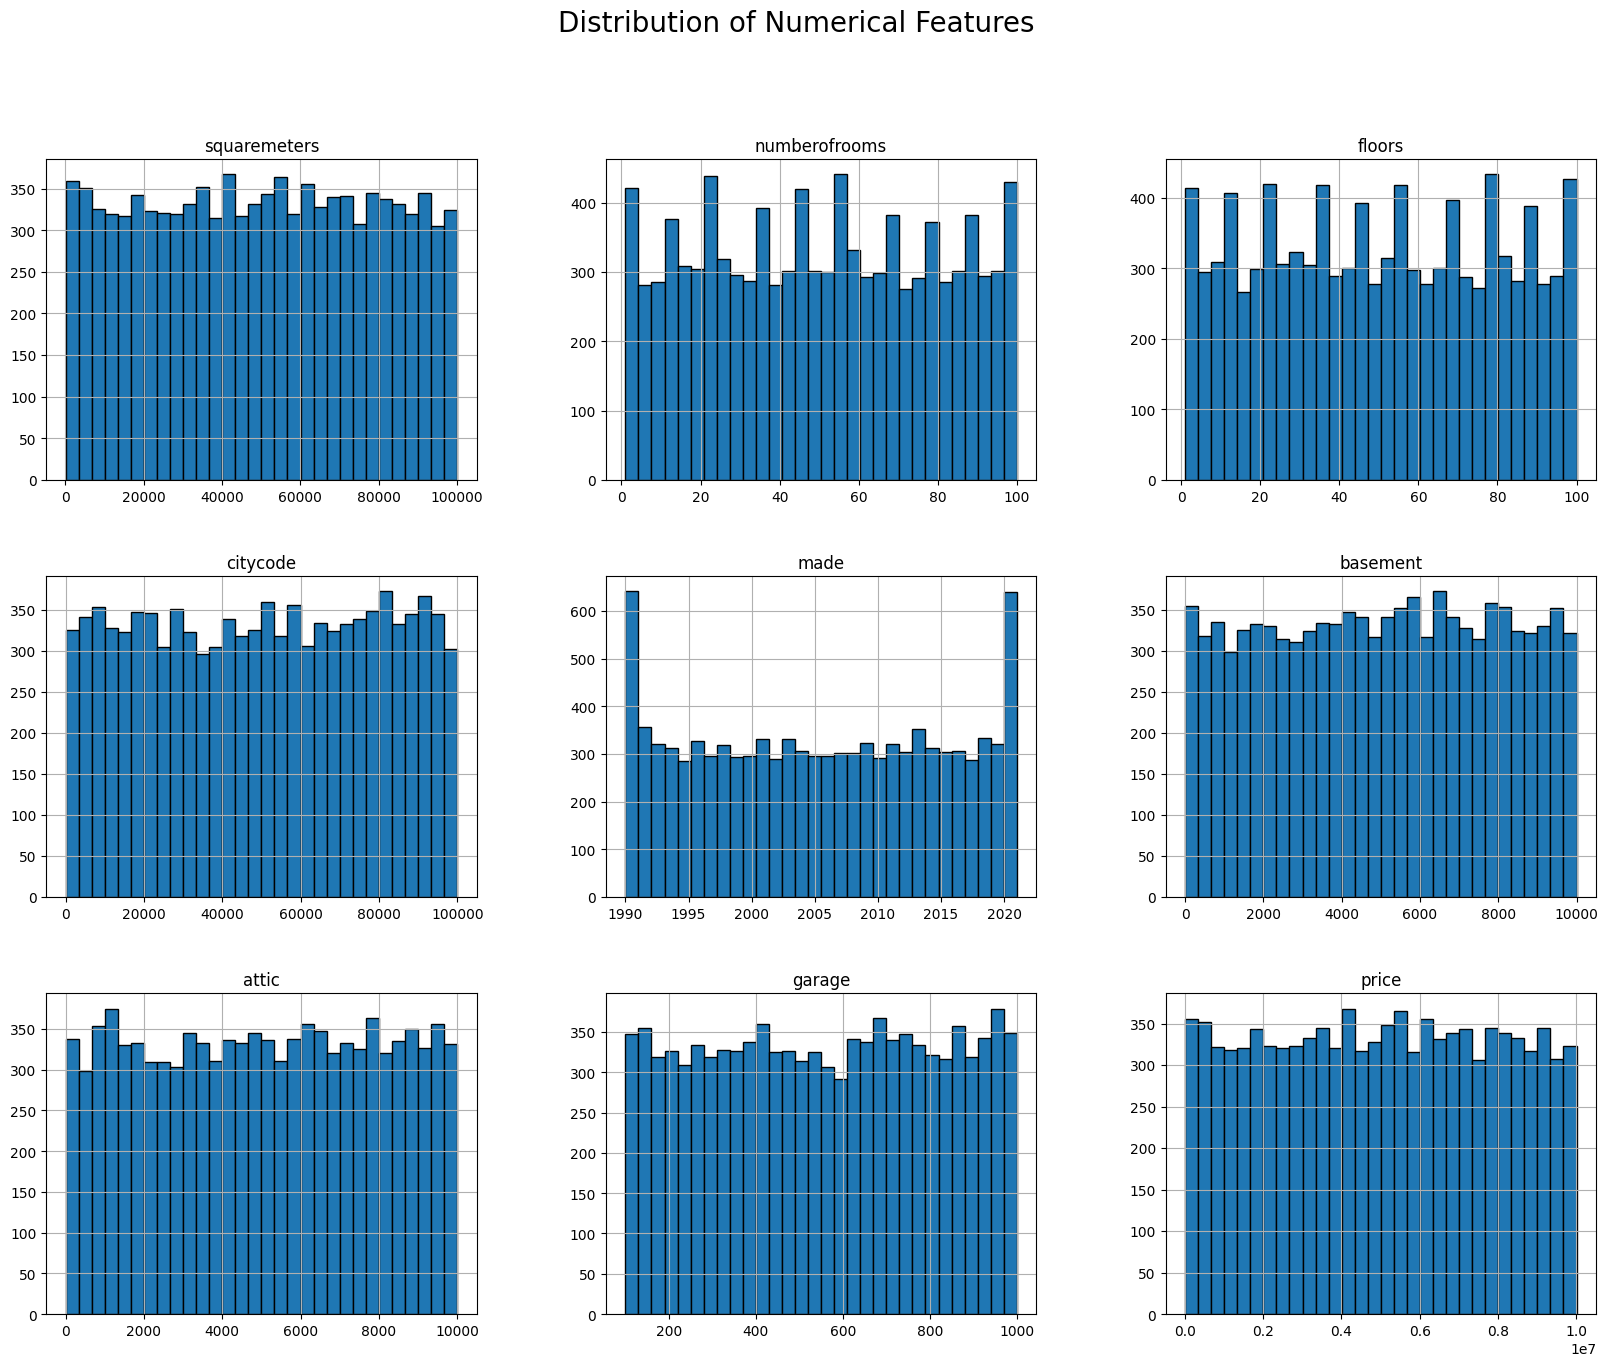

In [115]:
# Plot numerical features
df[numerical_cols].hist(figsize=(20, 15), bins=30, edgecolor='black')
plt.suptitle('Distribution of Numerical Features', fontsize=20)
plt.show()

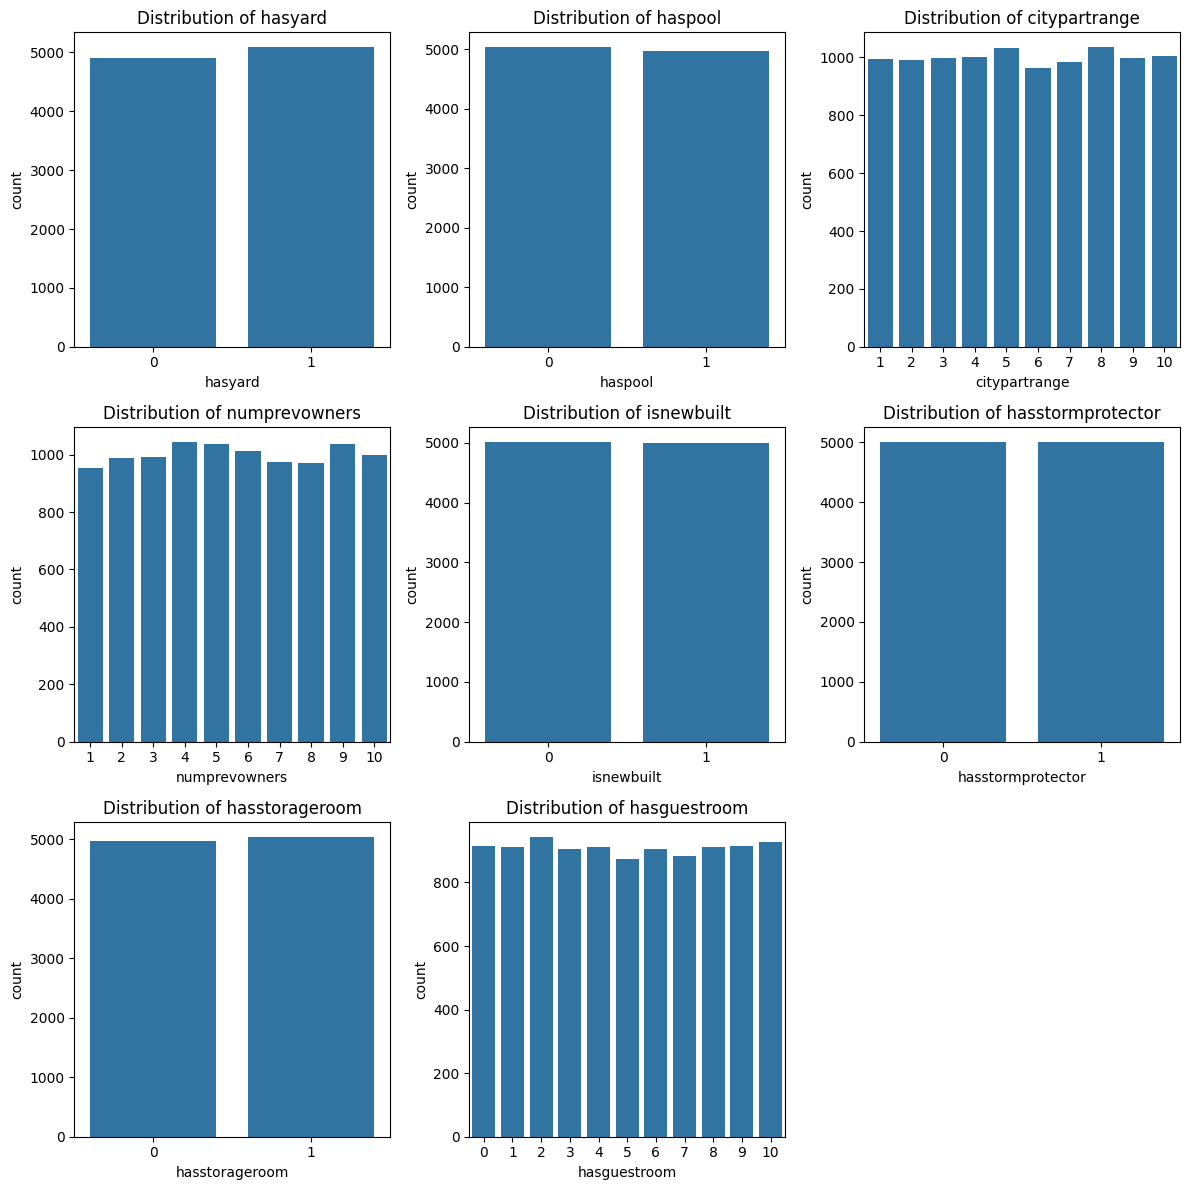

In [116]:
# Number of rows and columns for the grid
rows, cols = 3, 3
fig, axes = plt.subplots(rows, cols, figsize=(12, 12))
axes = axes.flatten()  # flatten to 1D array for easy iteration

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=df, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

# Remove any empty subplots if categorical_cols < rows*cols
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [117]:
#df['price_log'] = np.log1p(df['price'])
#df['price_log']

### 'price' target feature

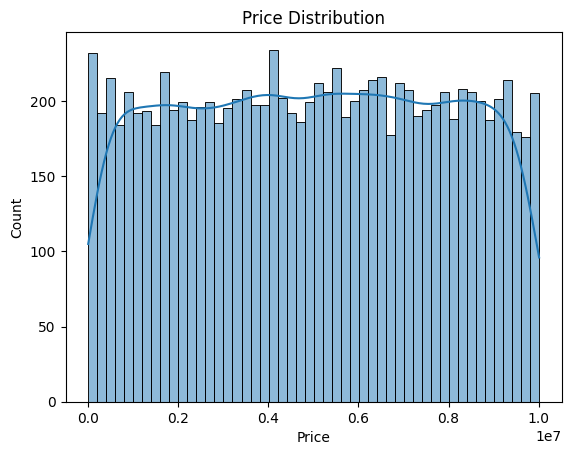

In [118]:
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.show()

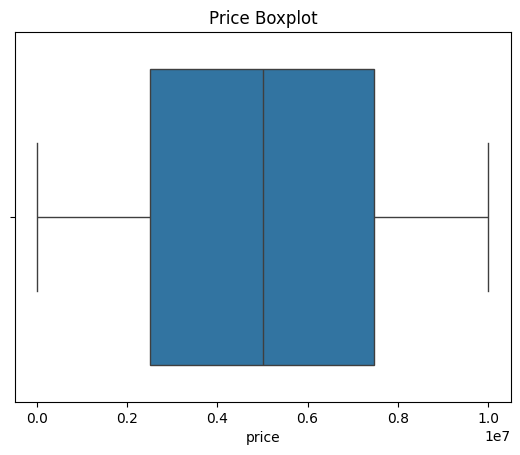

In [119]:
sns.boxplot(x=df['price'])
plt.title('Price Boxplot')
plt.show()

In [120]:
from scipy.stats import skew, kurtosis

print("Skewness:", skew(df['price']))
print("Kurtosis:", kurtosis(df['price']))

Skewness: -0.006448191698178405
Kurtosis: -1.1850410631048522


* Skewness ≈ 0 (-0.006) → The distribution is almost perfectly symmetric.
* Kurtosis < 0 (-1.185) → Slightly flatter than a normal distribution (light tails).
* Implication: The price target is well-behaved, with no extreme skew or heavy tails.
* Modeling impact: No transformation (e.g., log) is needed; standard regression models can be used directly.


### Exploratory Data Analysis

In [121]:
df.columns

Index(['squaremeters', 'numberofrooms', 'hasyard', 'haspool', 'floors',
       'citycode', 'citypartrange', 'numprevowners', 'made', 'isnewbuilt',
       'hasstormprotector', 'basement', 'attic', 'garage', 'hasstorageroom',
       'hasguestroom', 'price'],
      dtype='str')

In [122]:
# Mean price by haspool
pool_group = df.groupby('haspool')['price'].mean().reset_index()
pool_group

,haspool,price
0,0,5.007943e+06
1,1,4.978765e+06


In [123]:
# Mean price by numberofrooms
numberofrooms_group = df.groupby('numberofrooms')['price'].mean().sort_values(ascending=False)
numberofrooms_group

numberofrooms
55    5.828663e+06
45    5.528581e+06
60    5.497667e+06
77    5.473578e+06
89    5.467661e+06
          ...     
42    4.536043e+06
1     4.529113e+06
33    4.414912e+06
18    4.401772e+06
71    4.151713e+06
Name: price, Length: 100, dtype: float64

In [124]:
target = 'price'

In [125]:
# Function to compute mean price by categorical feature
def mean_price_by_category(df, target, categorical_cols):
    """
    Returns a dictionary of dataframes with mean target values for each categorical column.

    Parameters:
        df: pandas DataFrame
        target: str, name of the target column (e.g., 'price')
        categorical_cols: list of categorical column names
    """
    result = {}
    for col in categorical_cols:
        # Group by the categorical column
        grouped = df.groupby(col)[target].mean().reset_index()
        # Format the numbers to readable integers
        grouped[target] = grouped[target].apply(lambda x: f"{x:,.0f}")
        result[col] = grouped
    return result


In [126]:
mean_price_by_category(df, target, categorical_cols )

{'hasyard':   hasyard      price
 0       0  5,011,363
 1       1  4,976,144,
 'haspool':   haspool      price
 0       0  5,007,943
 1       1  4,978,765,
 'citypartrange':   citypartrange      price
 0             1  4,903,580
 1             2  4,931,873
 2             3  5,026,029
 3             4  4,932,945
 4             5  5,059,792
 5             6  4,990,101
 6             7  5,069,665
 7             8  5,082,120
 8             9  4,954,627
 9            10  4,978,567,
 'numprevowners':   numprevowners      price
 0             1  4,824,585
 1             2  5,007,744
 2             3  5,065,798
 3             4  4,927,437
 4             5  5,037,837
 5             6  4,862,583
 6             7  5,050,958
 7             8  4,944,788
 8             9  5,094,757
 9            10  5,109,954,
 'isnewbuilt':   isnewbuilt      price
 0          0  5,024,015
 1          1  4,962,770,
 'hasstormprotector':   hasstormprotector      price
 0                 0  4,971,884
 1               

# Key Insights from Groupby Analysis

### hasyard
- **No yard:** 5,011,363  
- **Has yard:** 4,976,144  
- Slightly higher price for houses without a yard (small difference).

### haspool
- **No pool:** 5,007,943  
- **Has pool:** 4,978,765  
- Small difference; pool presence doesn’t drastically change price.

### citypartrange
- Prices vary across city parts (**4,903,580 → 5,082,120**)  
- Some city parts (7 & 8) have the highest average prices.

### numprevowners
- Minor variations (**4,824,585 → 5,109,954**)  
- Number of previous owners doesn’t clearly correlate with price.

### isnewbuilt
- **New build (1):** 4,962,770  
- **Old build (0):** 5,024,015  
- Older houses have slightly higher mean price.

### hasstormprotector
- **No:** 4,971,884  
- **Yes:** 5,015,020  
- Storm protector slightly increases average price.

### hasstorageroom
- **No:** 5,003,536  
- **Yes:** 4,983,479  
- Small negative effect, almost negligible.

### hasguestroom
- Prices fluctuate between **4,807,832 → 5,129,961**  
- No clear linear trend; categorical treatment is appropriate.

In [127]:
import math

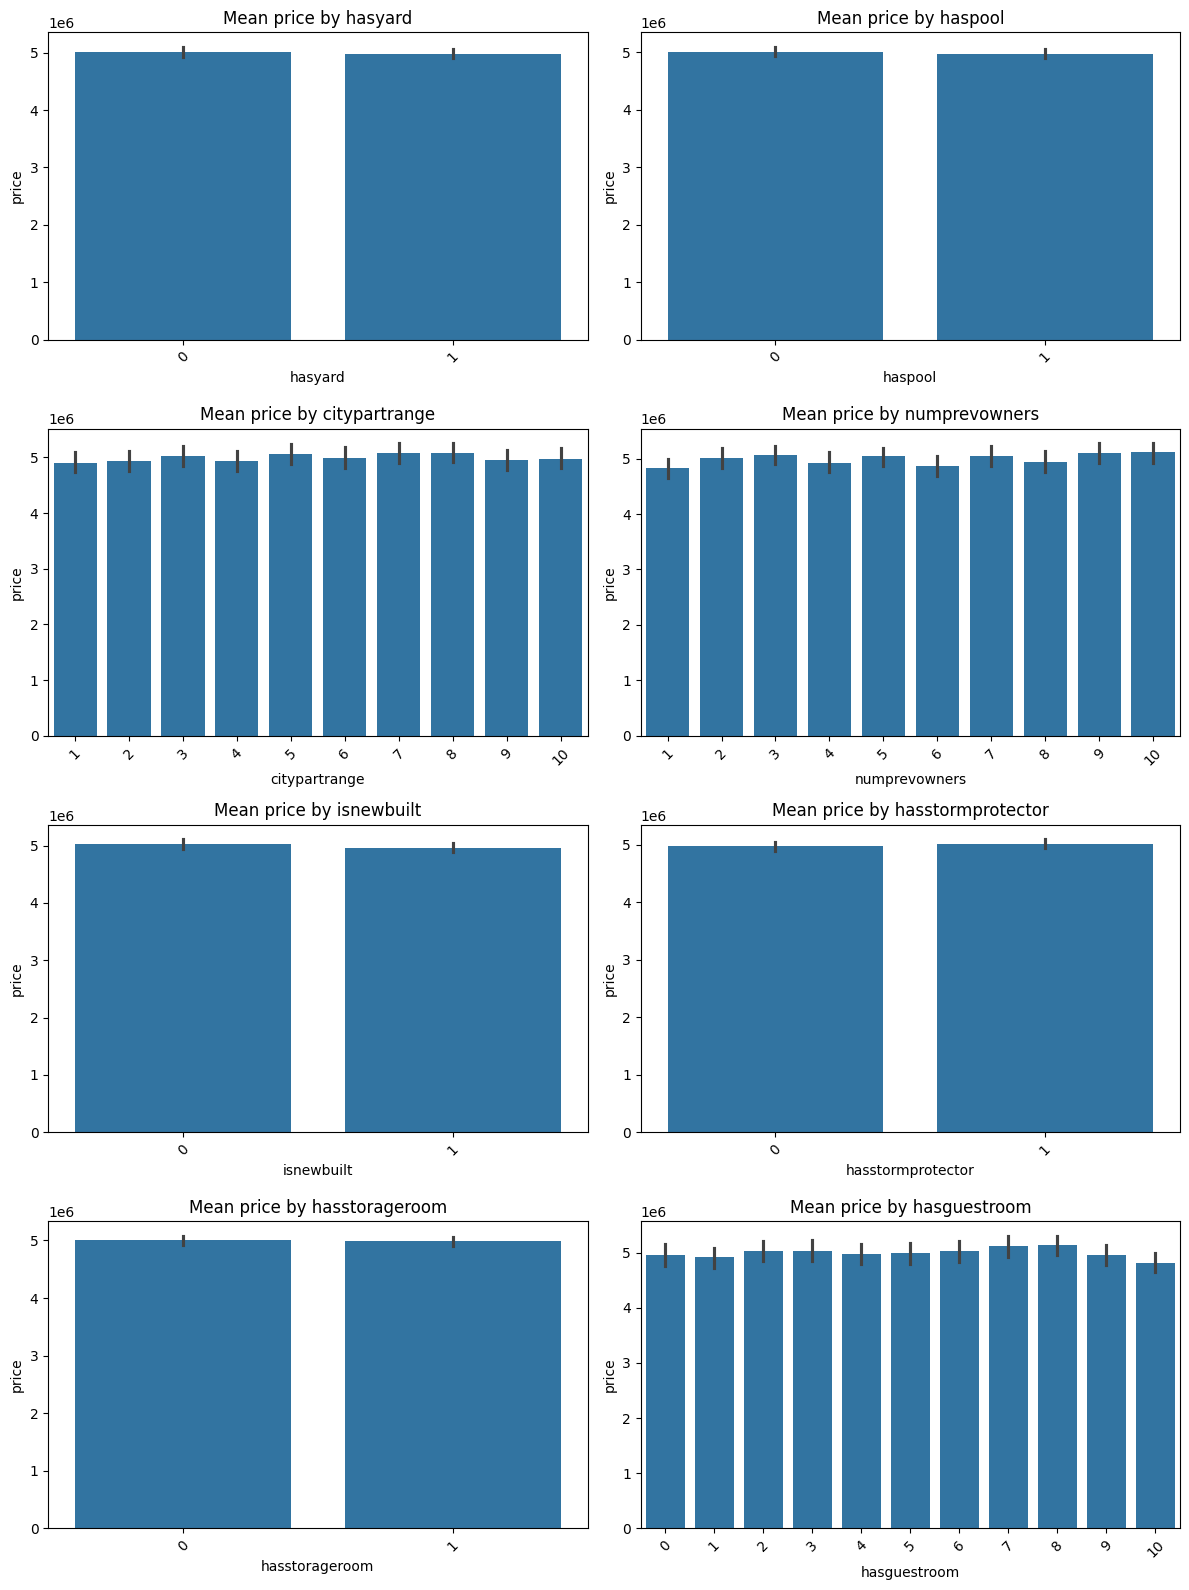

In [128]:
def plot_mean_price_by_category(df, target, categorical_cols):
    n_cols = 2  # number of columns in the grid
    n_rows = math.ceil(len(categorical_cols)/n_cols)  # calculate rows dynamically
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows*4))
    axes = axes.flatten()  # flatten in case of multiple rows
    
    for i, col in enumerate(categorical_cols):
        sns.barplot(x=col, y=target, data=df, ax=axes[i])
        axes[i].set_title(f'Mean {target} by {col}')
        axes[i].tick_params(axis='x', rotation=45)
    
    # Remove empty subplots
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

# Now call it
plot_mean_price_by_category(df, target, categorical_cols)

In [129]:
for col in categorical_cols:
    summary = df.groupby(col)['price'].agg(['mean', 'median']).round(0)
    print(f"\n{col}")
    print(summary)


hasyard
              mean     median
hasyard                      
0        5011363.0  5014755.0
1        4976144.0  5016998.0

haspool
              mean     median
haspool                      
0        5007943.0  5027915.0
1        4978765.0  5006138.0

citypartrange
                    mean     median
citypartrange                      
1              4903580.0  4886434.0
2              4931873.0  4963035.0
3              5026029.0  5107816.0
4              4932945.0  4941102.0
5              5059792.0  5096676.0
6              4990101.0  4986838.0
7              5069665.0  5230357.0
8              5082120.0  5030382.0
9              4954627.0  4872303.0
10             4978567.0  5024096.0

numprevowners
                    mean     median
numprevowners                      
1              4824585.0  4791242.0
2              5007744.0  5030780.0
3              5065798.0  5076210.0
4              4927437.0  4782452.0
5              5037837.0  4977036.0
6              4862583.0  49

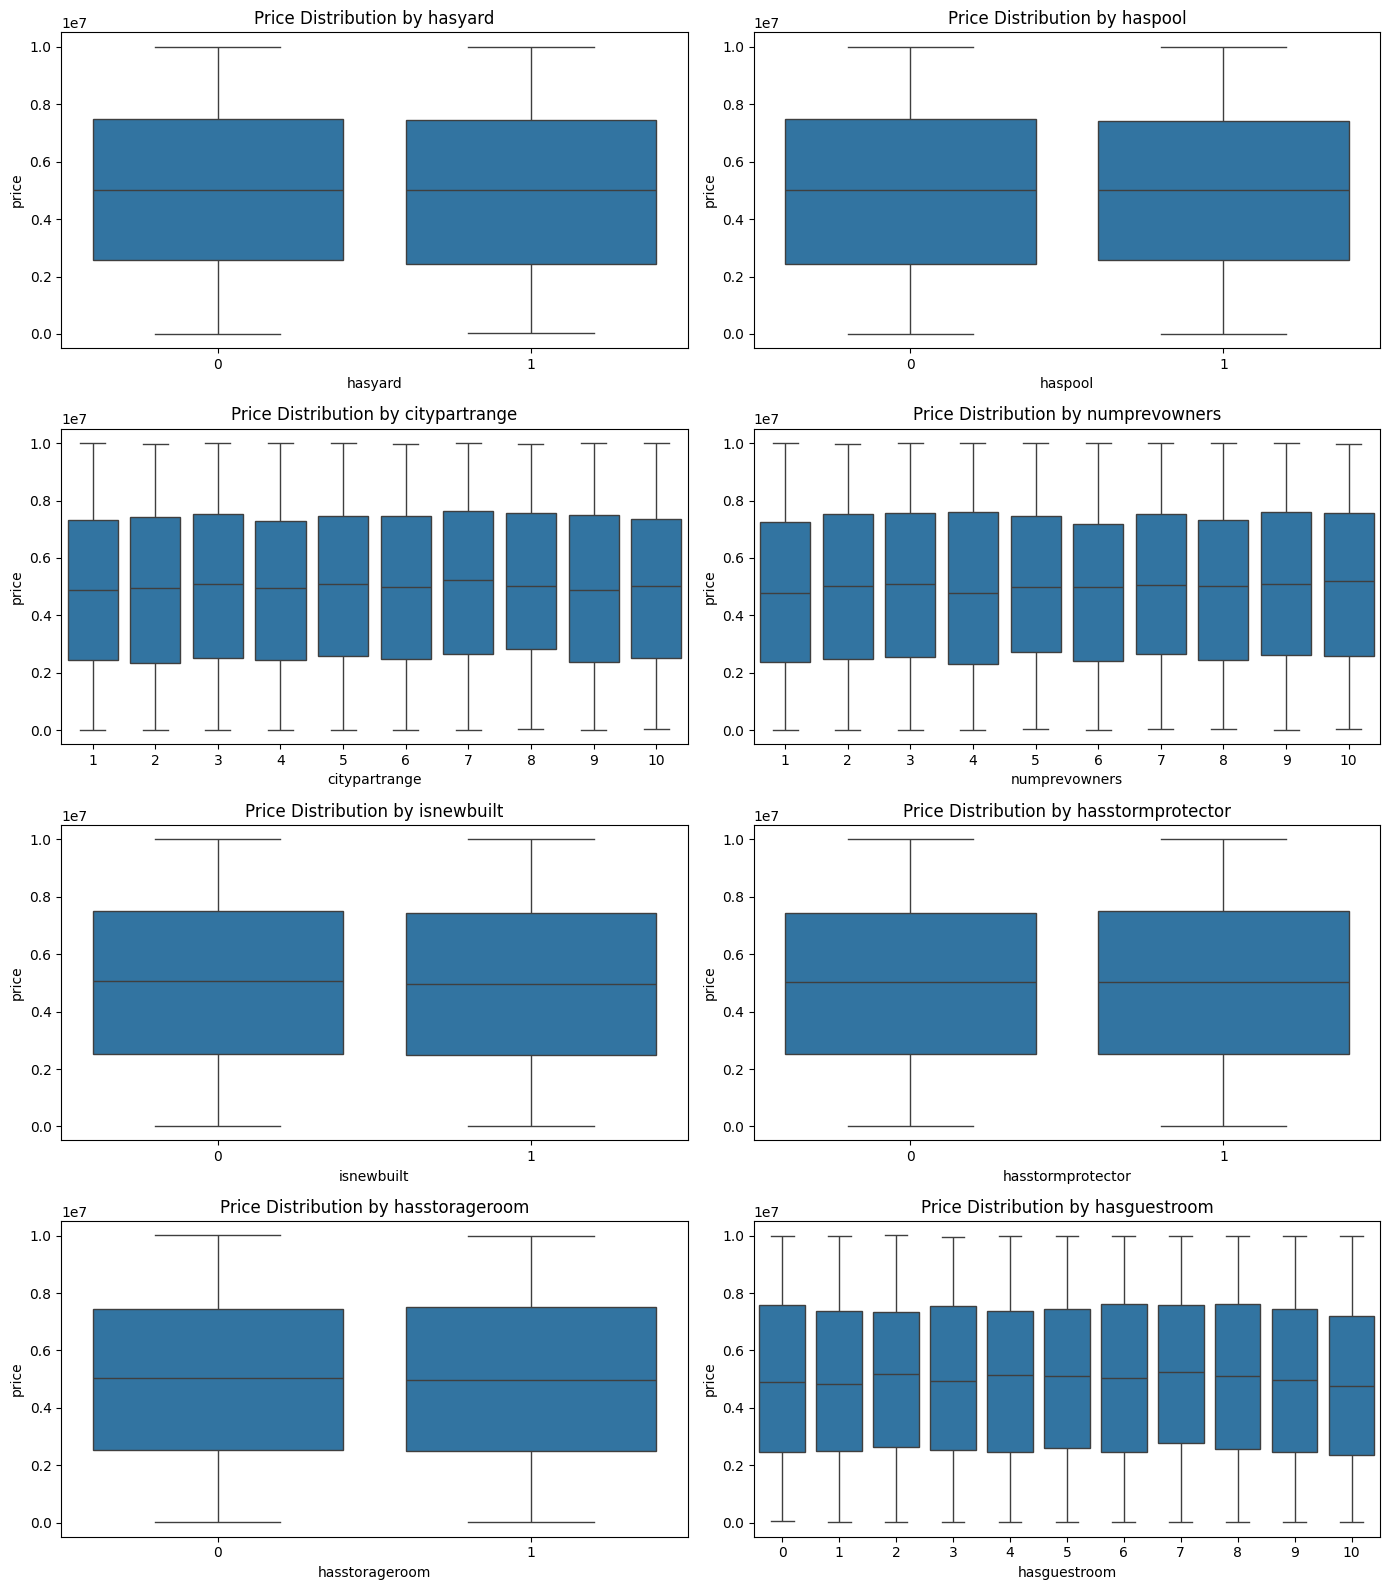

In [130]:
n_cols = 2
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.boxplot(data=df, x=col, y='price', ax=axes[i])
    axes[i].set_title(f'Price Distribution by {col}')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Numerical Features vs price

In [131]:
# Correlation with price
corr_matrix = df[numerical_cols].corr()
corr_matrix

,squaremeters,numberofrooms,floors,citycode,made,basement,attic,garage,price
squaremeters,1.000000,0.009573,0.001109,-0.001541,-0.007207,-0.003960,-0.000588,-0.017246,0.999999
numberofrooms,0.009573,1.000000,0.022244,0.009040,0.003978,-0.013990,0.012061,0.023188,0.009591
floors,0.001109,0.022244,1.000000,0.002207,0.005022,0.006228,-0.000270,0.011303,0.001654
citycode,-0.001541,0.009040,0.002207,1.000000,0.009266,0.002652,-0.002019,-0.002208,-0.001539
made,-0.007207,0.003978,0.005022,0.009266,1.000000,-0.005506,0.013773,0.005687,-0.007210
basement,-0.003960,-0.013990,0.006228,0.002652,-0.005506,1.000000,-0.003180,0.000117,-0.003967
attic,-0.000588,0.012061,-0.000270,-0.002019,0.013773,-0.003180,1.000000,-0.000611,-0.000600
garage,-0.017246,0.023188,0.011303,-0.002208,0.005687,0.000117,-0.000611,1.000000,-0.017229
price,0.999999,0.009591,0.001654,-0.001539,-0.007210,-0.003967,-0.000600,-0.017229,1.000000


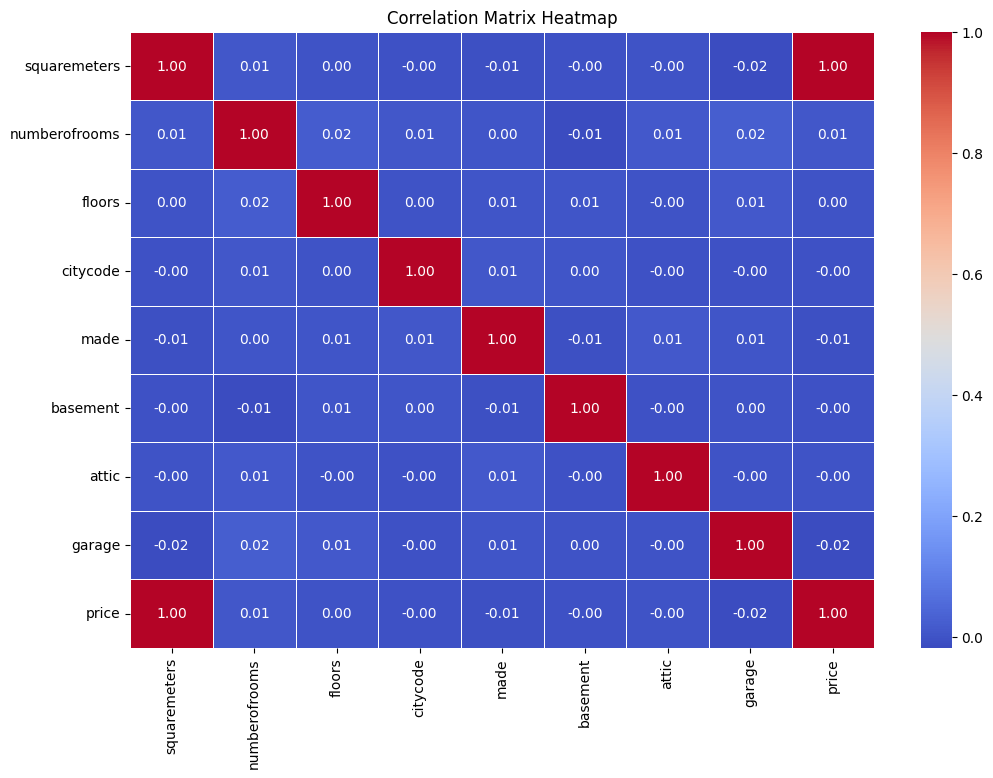

In [132]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Matrix Heatmap')
plt.show()

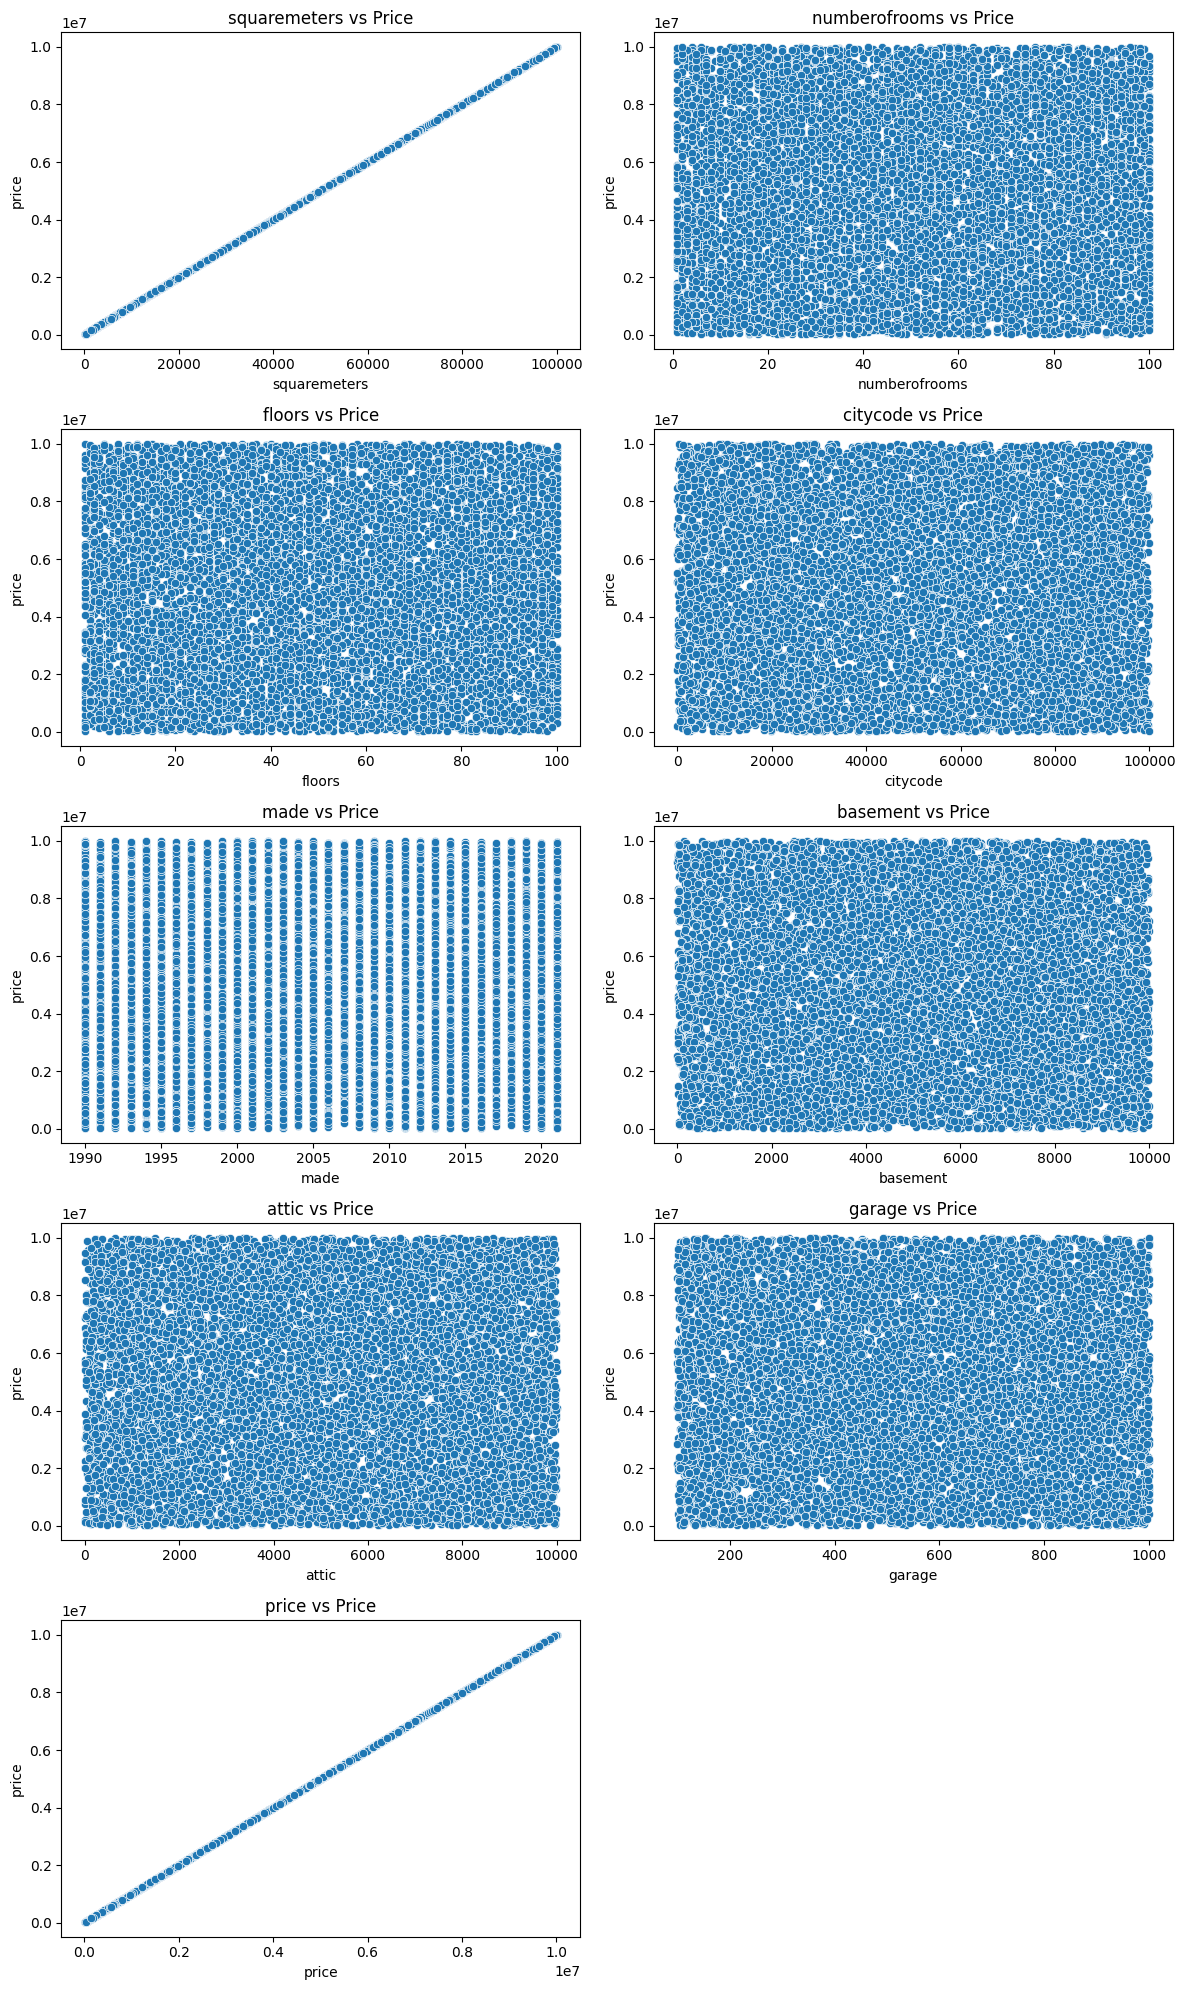

In [133]:

# Set up grid for plots
n_cols = 2
n_rows = math.ceil(len(numerical_cols)/n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows*4))
axes = axes.flatten()

# Create scatterplots
for i, col in enumerate(numerical_cols):
    sns.scatterplot(data=df, x=col, y='price', ax=axes[i])
    axes[i].set_title(f'{col} vs Price')
    
# Remove any unused axes
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [134]:
# Convert categorical to integer temporarily
df['hasyard_num'] = df['hasyard'].cat.codes  # 0/1 encoding

# Create interaction feature
df['squaremeters_hasyard'] = df['squaremeters'] * df['hasyard_num']

# Quick check
df[['squaremeters', 'hasyard', 'squaremeters_hasyard']].head()

,squaremeters,hasyard,squaremeters_hasyard
0,75523,0,0
1,80771,1,80771
2,55712,0,0
3,32316,0,0
4,70429,1,70429


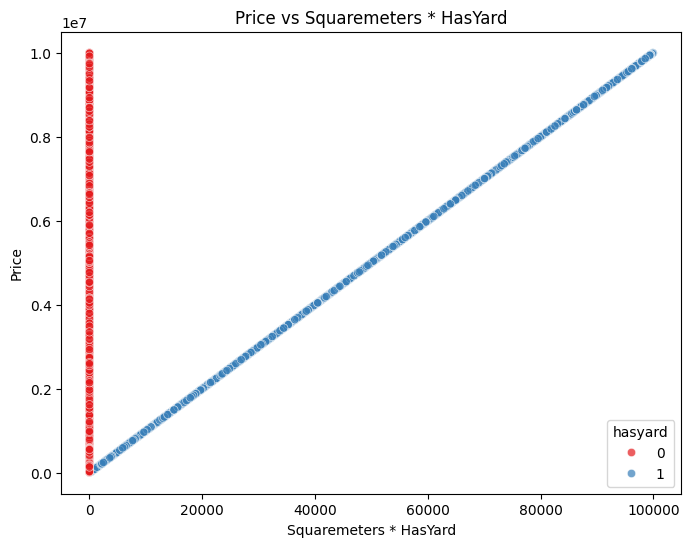

In [135]:
# Scatterplot for squaremeters_hasyard vs price
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='squaremeters_hasyard',
    y='price',
    hue='hasyard',  # show yard presence
    palette='Set1',
    alpha=0.7
)
plt.title('Price vs Squaremeters * HasYard')
plt.xlabel('Squaremeters * HasYard')
plt.ylabel('Price')
plt.show()